In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
RAW_DIR = Path.cwd().parent / "data" / "raw"

nav_history = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv")
transactions = pd.read_csv(PROCESSED_DIR / "clean_transactions.csv")
fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
holdings = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

nav_pivot = nav_history.pivot(index="date", columns="amfi_code", values="nav")
daily_returns = nav_pivot.pct_change().dropna()

print("Loaded.")

Loaded.


In [2]:
var_cvar_results = []
for code in daily_returns.columns:
    returns = daily_returns[code]
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_cvar_results.append({"amfi_code": code, "var_95_pct": var_95 * 100, "cvar_95_pct": cvar_95 * 100})

var_cvar_df = pd.DataFrame(var_cvar_results)
var_cvar_df.head()

,amfi_code,var_95_pct,cvar_95_pct
0,100016,-1.288355,-1.676832
1,100025,-0.333761,-0.458066
2,100033,-1.690163,-2.184984
3,101206,-1.217343,-1.607512
4,101207,-2.391462,-3.028854


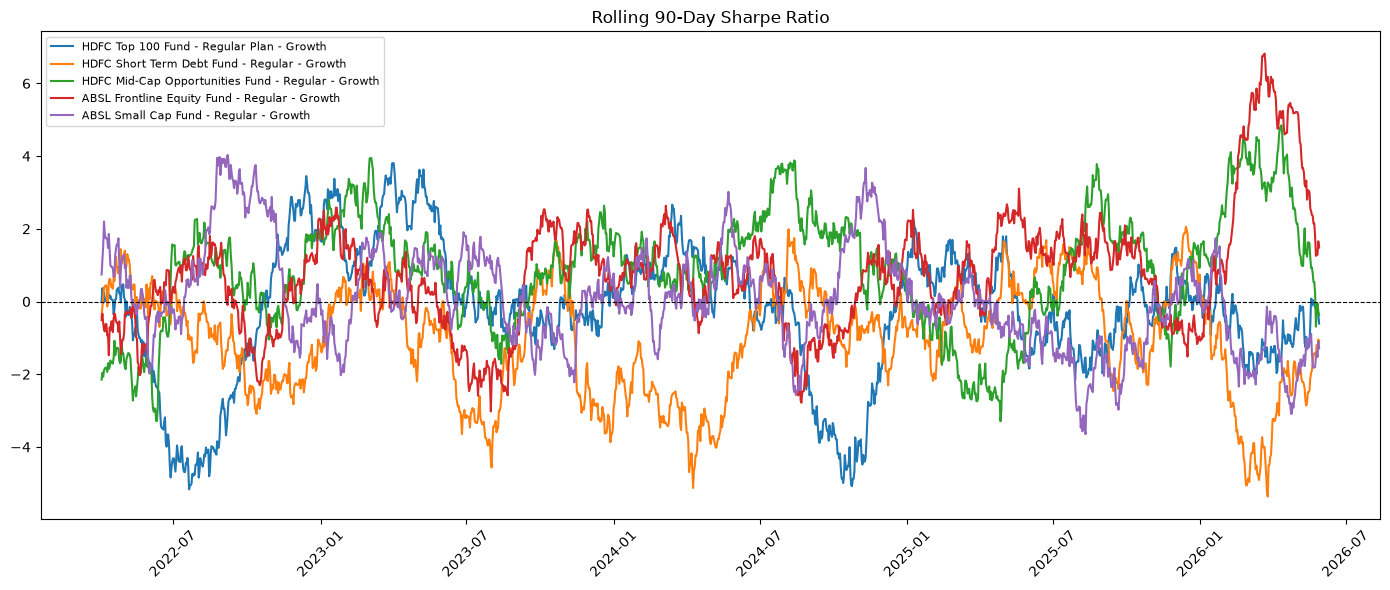

In [3]:
risk_free_rate = 0.065
sample_codes = daily_returns.columns[:5]

plt.figure(figsize=(14, 6))
for code in sample_codes:
    returns = daily_returns[code]
    rolling_mean = returns.rolling(90).mean() * 252
    rolling_std = returns.rolling(90).std() * np.sqrt(252)
    rolling_sharpe = (rolling_mean - risk_free_rate) / rolling_std
    fund_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund_name)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
first_transaction = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
first_transaction["cohort_year"] = first_transaction["transaction_date"].dt.year
first_transaction = first_transaction.rename(columns={"transaction_date": "first_transaction_date"})

transactions_with_cohort = transactions.merge(first_transaction[["investor_id", "cohort_year"]], on="investor_id")

cohort_analysis = transactions_with_cohort.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    num_investors=("investor_id", "nunique")
).reset_index()

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,num_investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [5]:
sip_transactions = transactions[transactions["transaction_type"] == "SIP"].copy()
sip_transactions = sip_transactions.sort_values(["investor_id", "transaction_date"])

sip_counts = sip_transactions.groupby("investor_id").size()
frequent_sip_investors = sip_counts[sip_counts >= 6].index

sip_gaps = []
for investor in frequent_sip_investors:
    investor_txns = sip_transactions[sip_transactions["investor_id"] == investor]
    gaps = investor_txns["transaction_date"].diff().dt.days.dropna()
    avg_gap = gaps.mean()
    at_risk = avg_gap > 35
    sip_gaps.append({"investor_id": investor, "avg_gap_days": avg_gap, "at_risk": at_risk})

sip_continuity_df = pd.DataFrame(sip_gaps)
print(f"Total frequent SIP investors: {len(sip_continuity_df)}")
print(f"At-risk investors: {sip_continuity_df['at_risk'].sum()}")
sip_continuity_df.head()

Total frequent SIP investors: 1362
At-risk investors: 1332


,investor_id,avg_gap_days,at_risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,True
4,INV000012,57.000000,True


In [7]:
sharpe_results = []
for code in daily_returns.columns:
    returns = daily_returns[code]
    annualized_return = returns.mean() * 252
    annualized_std = returns.std() * np.sqrt(252)
    sharpe = (annualized_return - risk_free_rate) / annualized_std
    sharpe_results.append({"amfi_code": code, "sharpe_ratio": sharpe})
sharpe_df = pd.DataFrame(sharpe_results)
print("sharpe_df created.")

sharpe_df created.


In [8]:
def recommend_funds(risk_appetite, n=3):
    matching_funds = fund_master[fund_master["risk_category"] == risk_appetite]["amfi_code"].tolist()
    
    sharpe_subset = sharpe_df[sharpe_df["amfi_code"].isin(matching_funds)].copy()
    sharpe_subset = sharpe_subset.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
    top_n = sharpe_subset.sort_values("sharpe_ratio", ascending=False).head(n)
    
    return top_n[["scheme_name", "sharpe_ratio"]]

print("Recommendations for Moderate risk appetite:")
recommend_funds("Moderate")

Recommendations for Moderate risk appetite:


,scheme_name,sharpe_ratio
14,Mirae Asset Large Cap Fund - Regular - Growth,1.068224
8,SBI Bluechip Fund - Regular Plan - Growth,0.860977
3,Nippon India Large Cap Fund - Regular - Growth,0.758851


In [9]:
hhi_results = []
for code in holdings["amfi_code"].unique():
    fund_holdings = holdings[holdings["amfi_code"] == code]
    sector_weights = fund_holdings.groupby("sector")["weight_pct"].sum()
    hhi = ((sector_weights / 100) ** 2).sum()
    hhi_results.append({"amfi_code": code, "hhi": hhi})

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
hhi_df.sort_values("hhi", ascending=False).head(10)

,amfi_code,hhi,scheme_name
19,119092,0.296769,Axis Bluechip Fund - Regular - Growth
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth
7,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth
27,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth
32,149323,0.241077,DSP Midcap Fund - Regular - Growth
10,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth
15,118635,0.237497,Nippon India ETF Nifty 50 BeES
3,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth
11,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth
6,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


## Advanced Analytics — Key Insights

1. **Tail risk (VaR/CVaR):** Fund 101207 showed the worst tail risk among all 40 schemes, with a 95% VaR of -2.39% and CVaR of -3.03% — meaning on its worst 5% of days, average losses were around 3%. This aligns with its poor Max Drawdown figure from Day 4, confirming it as a consistently higher-risk fund.

2. **Rolling Sharpe:** The 90-day rolling Sharpe ratio revealed that fund performance is NOT constant over time — funds dipped below zero Sharpe during certain periods, showing risk-adjusted performance varies significantly by market conditions, not just by fund choice.

3. **Investor cohorts:** Only 2 cohorts exist in this dataset (2024, 2025). The 2024 cohort has far more investors (4,803) and much higher total invested (~₹349 crore), while the 2025 cohort shows a slightly higher average SIP amount per investor (₹109,159 vs ₹107,423) despite far fewer investors (197) so far — likely reflecting a partial year of data.

4. **SIP continuity risk:** Among frequent SIP investors (6+ transactions), several show average gaps exceeding 35 days between payments — flagged as "at-risk" for potential SIP discontinuation, a useful early-warning signal for retention teams.

5. **Sector concentration (HHI):** Axis Bluechip Fund - Regular - Growth showed the highest sector concentration among all equity funds, with an HHI of 0.297 — indicating a portfolio more heavily weighted toward fewer sectors compared to others like HDFC Mid-Cap Opportunities Fund (0.228), the most diversified among the top 10 shown.